In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [10]:
PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

prices = pd.read_parquet(DATA_PROCESSED / "prices.parquet")
returns = pd.read_parquet(DATA_PROCESSED / "returns.parquet")

prices.shape, returns.shape

((2516, 30), (2515, 30))

In [11]:
feature_dict = {}

feature_dict["return_1d"] = returns
feature_dict["volatility_20"] = returns.rolling(20).std()
feature_dict["volatility_60"] = returns.rolling(60).std()

feature_dict["momentum_20"] = prices / prices.shift(20) - 1
feature_dict["momentum_60"] = prices / prices.shift(60) - 1
feature_dict["momentum_120"] = prices / prices.shift(120) - 1

In [13]:
features_list = []

for feature_name, df in feature_dict.items():
    tmp = df.copy()
    tmp.columns = pd.MultiIndex.from_product(
        [tmp.columns, [feature_name]],
        names=["ticker", "feature"]
    )
    features_list.append(tmp)

features = pd.concat(features_list, axis=1)

features = features.sort_index(axis=1)
features = features.dropna()

features.head()

ticker             AAPL                                                  \
feature    momentum_120 momentum_20 momentum_60 return_1d volatility_20   
Date                                                                      
2015-06-25     0.175687   -0.032478    0.028952 -0.004762      0.006550   
2015-06-26     0.202652   -0.027096    0.024382 -0.005882      0.006226   
2015-06-29     0.181477   -0.046039   -0.002153 -0.017515      0.007136   
2015-06-30     0.173559   -0.034857   -0.010962  0.007227      0.007425   
2015-07-01     0.140679   -0.027052    0.008879  0.009328      0.007807   

ticker                           ABBV                                    ...  \
feature    volatility_60 momentum_120 momentum_20 momentum_60 return_1d  ...   
Date                                                                     ...   
2015-06-25      0.011349     0.076454    0.034830    0.202580  0.008668  ...   
2015-06-26      0.011376     0.107158    0.058117    0.244210  0.009167  ...   
2015-06-29      0.011558     0.060869    0.003735    0.188163 -0.046552  ...   
2015-06-30      0.011402     0.019810    0.008556    0.175964  0.000149  ...   
2015-07-01      0.011383     0.029082    0.022385    0.182441  0.019646  ...   

ticker             WMT                                                XOM  \
feature    momentum_60 return_1d volatility_20 volatility_60 momentum_120   
Date                                                                        
2015-06-25   -0.120808 -0.007184      0.006028      0.008990    -0.081534   
2015-06-26   -0.100791  0.003618      0.006002      0.008749    -0.056484   
2015-06-29   -0.109739 -0.009706      0.005989      0.008805    -0.063205   
2015-06-30   -0.118686 -0.006861      0.006078      0.008802    -0.068347   
2015-07-01   -0.101445  0.013394      0.006868      0.009008    -0.092742   

ticker                                                                    
feature    momentum_20 momentum_60 return_1d volatility_20 volatility_60  
Date                                                                      
2015-06-25   -0.013864   -0.004421 -0.008857      0.005970      0.007787  
2015-06-26   -0.015728    0.001109 -0.000834      0.005956      0.007744  
2015-06-29   -0.027135   -0.009431 -0.012402      0.006499      0.007905  
2015-06-30   -0.022786   -0.014588  0.004588      0.006628      0.007822  
2015-07-01   -0.030371   -0.031472 -0.009976      0.006916      0.007859  

[5 rows x 180 columns]

In [14]:
print("features shape:", features.shape)
print("date range:", features.index.min(), "->", features.index.max())
print("n tickers:", len(features.columns.get_level_values("ticker").unique()))
print("features:", list(features.columns.get_level_values("feature").unique()))

features shape: (2396, 180)
date range: 2015-06-25 00:00:00 -> 2024-12-31 00:00:00
n tickers: 30
features: ['momentum_120', 'momentum_20', 'momentum_60', 'return_1d', 'volatility_20', 'volatility_60']


In [15]:
features.to_parquet(DATA_PROCESSED / "features.parquet")

In [16]:
features_check = pd.read_parquet(DATA_PROCESSED / "features.parquet")

features_check.shape

(2396, 180)

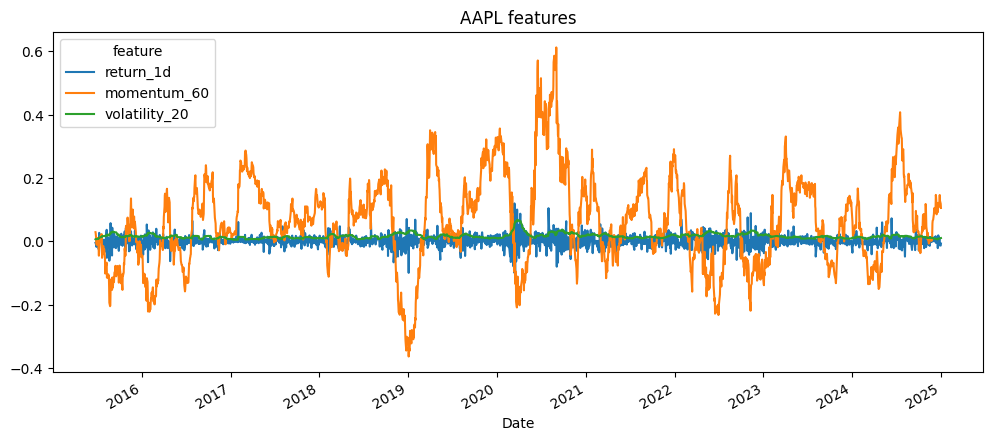

In [17]:
ticker = "AAPL"

features[ticker][["return_1d", "momentum_60", "volatility_20"]].plot(
    figsize=(12, 5),
    title=f"{ticker} features"
)

plt.show()